In [1]:
using BenchmarkTools

In [2]:
const x32 = rand(Float32, 10_000_000)
const x64 = rand(Float64, 10_000_000)

10000000-element Vector{Float64}:
 0.805259188284758
 0.8321233135503802
 0.054567668382558554
 0.9011109440700695
 0.6999838089695145
 0.6004244022749177
 0.43813449573352303
 0.41881199053760143
 0.33515511486681704
 0.2697673747707823
 ⋮
 0.7535121119519017
 0.5860781509102165
 0.38520983768217076
 0.8282253381147929
 0.3320205946760445
 0.839692300532999
 0.044070600495050405
 0.519258546513863
 0.5377095051817429

In [3]:
@btime exp.($x32)

  54.520 ms (2 allocations: 38.15 MiB)


10000000-element Vector{Float32}:
 1.1727828
 1.2437199
 1.0785525
 2.0121474
 2.2793703
 1.5921317
 1.138155
 2.0386088
 1.1461308
 1.0967208
 ⋮
 1.973083
 1.1347376
 2.3359458
 1.9074211
 1.9559222
 2.3208375
 1.0983429
 1.8492664
 1.2706985

In [4]:
@btime exp.($x64)

  46.375 ms (2 allocations: 76.29 MiB)


10000000-element Vector{Float64}:
 2.2372762994845643
 2.2981933483500128
 1.0560839374877657
 2.4623371110272947
 2.0137201030029503
 1.822892275875333
 1.5498133366843123
 1.5201545244867256
 1.3981572433776661
 1.309659755393914
 ⋮
 2.1244482294958424
 1.796927300437113
 1.4699227342612244
 2.2892524840873287
 1.3937815526964934
 2.3156543415413218
 1.0450561337643998
 1.6807809666700912
 1.7120808553245543

In [13]:
function fastexp(x::Float32)
    xp = x * 1.442695041f0
    fxp = floor(xp)
    f = xp - fxp
    i = Int(fxp)
    
    # Polynomial approximation for 2^f
    two_to_f = 1.0f0 + f * (0.695556856f0 + f * (0.226173572f0 + f * 0.0781455737f0))
    
    # Get exponent from binary representation
    bits = reinterpret(UInt32, two_to_f)
    exponent = Int((bits >> 23) & 0xFF) - 127 + i
    
    if exponent < -126 
        return 0.0f0
    elseif exponent > 127
        return Inf32
    end
    
    bits = (bits & 0b10000000011111111111111111111111) | (UInt32(exponent + 127) << 23)
    return reinterpret(Float32, bits)
end

function fastexp(x::Float64)
    xp = x * 1.4426950408889634
    fxp = floor(xp)
    f = xp - fxp
    i = Int(fxp)
    
    # Polynomial approximation for 2^f (coefficients adjusted for Float64 precision)
    two_to_f = 1.0 + f * (0.6931471805599453 + f * (0.2402265069591007 + f * 0.0855989669963166))
    
    bits = reinterpret(UInt64, two_to_f)
    exponent = Int((bits >> 52) & 0x7FF) - 1023 + i
    
    if exponent < -1022
        return 0.0
    elseif exponent > 1023
        return Inf
    end
    
    bits = (bits & 0x800FFFFFFFFFFFFF) | (UInt64(exponent + 1023) << 52)
    return reinterpret(Float64, bits)
 end

fastexp (generic function with 2 methods)

In [11]:
@btime fastexp.($x32)

  30.712 ms (2 allocations: 38.15 MiB)


10000000-element Vector{Float32}:
 1.1728413
 1.2436936
 1.0786762
 2.0121872
 2.2795582
 1.5921154
 1.1382504
 2.0387213
 1.1462185
 1.0968429
 ⋮
 1.973029
 1.1348361
 2.336074
 1.9074848
 1.9559059
 2.3209827
 1.0984645
 1.8493803
 1.2706434

In [14]:
@btime fastexp.($x64)

  34.046 ms (2 allocations: 76.29 MiB)


10000000-element Vector{Float64}:
 2.237517517867116
 2.298646516243272
 1.0560982472378315
 2.4638001059697405
 2.013720160573293
 1.8363165743121614
 1.5557333627278502
 1.5253957960797204
 1.4009963442607993
 1.3112007460534176
 ⋮
 2.1244868652446356
 1.809565799756204
 1.4740952598698855
 2.2896694264018196
 1.3965472135529087
 2.316183554554334
 1.0450637102380187
 1.6900600548325548
 1.7222361630591454

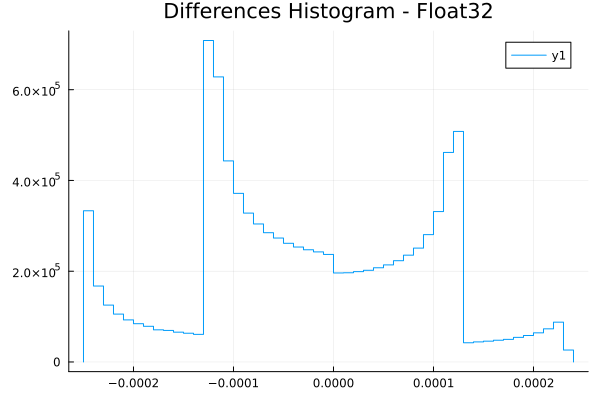

In [18]:
using Plots

d32 = exp.(x32) .- fastexp.(x32)
histogram(d32, bins=50, title="Differences Histogram - Float32")

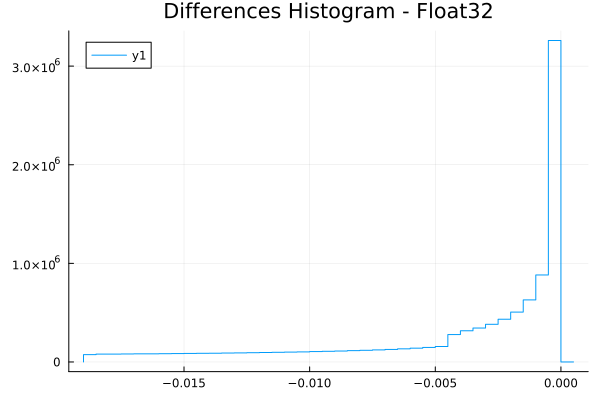

In [19]:
d64 = exp.(x64) .- fastexp.(x64)
histogram(d64, bins=50, title="Differences Histogram - Float32")